# Smart Beta Equity Portfolio Optimization Using Factor Models and Machine Learning

## Abstract

This project evaluates whether machine learning-based return prediction models can improve portfolio construction relative to traditional linear factor approaches in an empirical asset management setting.

Using CRSP-style monthly equity return data combined with Fama-French Five Factors, we compare two approaches for estimating expected stock returns: (1) a traditional Ordinary Least Squares (OLS) factor model and (2) a Random Forest (RF) model designed to capture nonlinear relationships and interactions across predictors.

Predicted returns are then incorporated into constrained mean-variance optimization (MVO) portfolios constructed under realistic long-only weight constraints. Portfolio performance is evaluated using cumulative returns, Sharpe ratios, and comparisons against equal-weight benchmark portfolios.

The results show that the Random Forest approach produces stronger out-of-sample portfolio performance and higher cumulative wealth growth relative to the traditional linear factor model. The findings suggest that nonlinear prediction methods may provide economically meaningful improvements in portfolio allocation when combined with disciplined portfolio optimization techniques.

# 1. Introduction

This project evaluates whether machine learning-based return prediction can improve portfolio construction relative to a traditional linear factor model.

Using CRSP-style monthly equity return data and Fama-French Five Factor data, we compare two return prediction approaches:

1. Ordinary Least Squares (OLS)
2. Random Forest (RF)

The predicted returns from each model are then used in a Mean-Variance Optimization (MVO) framework to construct long-only portfolios with weight caps.

The main research question is:

> Can nonlinear machine learning predictions improve risk-adjusted portfolio performance relative to a traditional factor-based approach?

# 2. Data Description and Processing

## 2.1 Data Sources

The project combines two primary datasets:

- CRSP-style monthly equity return data
- Fama-French Five Factor monthly data

The stock-level dataset includes:

- Monthly returns
- Monthly prices
- Market capitalization
- Share counts
- PERMNO identifiers
- Ticker symbols

The Fama-French dataset provides the following factors:

- Market excess return (Mkt-RF)
- Size factor (SMB)
- Value factor (HML)
- Profitability factor (RMW)
- Investment factor (CMA)
- Risk-free rate (RF)

The two datasets were merged using monthly date keys.

The final merged dataset contains monthly stock-level observations combined with Fama-French factor information and engineered predictive variables used for return forecasting and portfolio construction.

## 2.2 Data Cleaning

Several preprocessing steps were performed to improve consistency and model usability.

The main cleaning procedures included:

- Removing duplicate observations
- Handling missing values
- Converting factor values from percentages to decimals
- Aligning monthly dates across datasets
- Constructing excess returns relative to the risk-free rate
- Filtering stocks with insufficient historical history

The target variable for prediction is next-month excess return:

$$
y_{i,t+1} = R_{i,t+1} - RF_{t+1}
$$

where:

- \(R_{i,t+1}\) represents the stock return
- \(RF_{t+1}\) represents the risk-free rate

Lagged return features and firm characteristics were additionally constructed to improve predictive capability.

## 2.3 Feature Engineering

Several predictive variables were created for modeling purposes.

These included:

- Lagged monthly returns
- Firm size measures
- Historical rolling statistics
- Fama-French factor exposures

Firm size was represented using the logarithm of market capitalization.

After generating model predictions, stocks were ranked each month based on predicted future returns. The top-ranked securities were selected into the investment universe used for portfolio construction.

The analysis primarily focuses on portfolios consisting of six selected equities per month.


# 3. Methodology

## 3.1 Ordinary Least Squares (OLS) Model

The first predictive approach uses an Ordinary Least Squares regression model.

OLS serves as the traditional finance benchmark because it estimates future excess returns as a linear function of financial predictors and factor variables.

The general OLS specification is:

$$
y_{i,t+1} =
\alpha +
\beta_1 X_{1,i,t} +
\beta_2 X_{2,i,t} +
\cdots +
\beta_k X_{k,i,t} +
\varepsilon_{i,t+1}
$$

where:

- \(y_{i,t+1}\) is next-month excess return
- \(X_{k,i,t}\) represents predictor variables
- \(\beta_k\) represents estimated coefficients
- \(\varepsilon_{i,t+1}\) is the error term

The OLS model is interpretable and closely aligned with traditional empirical asset pricing approaches. However, it may struggle to capture nonlinear relationships and interaction effects present in financial markets.

## 3.2 Random Forest Model

The second predictive approach uses a Random Forest regression model.

Random Forest is a machine learning ensemble method that combines multiple decision trees to generate predictions.

Unlike OLS, Random Forest does not impose linearity assumptions and can capture:

- Nonlinear relationships
- Interaction effects between variables
- More flexible predictive patterns

The Random Forest model generates predicted next-month excess returns for each stock using the same underlying financial information available to the OLS specification.

The resulting predictions are then used to rank securities and construct optimized portfolios.

## 3.3 Mean-Variance Optimization (MVO)

After generating predicted returns from both models, the project uses Mean-Variance Optimization (MVO) to construct portfolios.

The optimization objective is to maximize the portfolio Sharpe ratio:

$$
\max_w
\frac{w^\top \mu}
{\sqrt{w^\top \Sigma w}}
$$

subject to:

$$
\sum_{i=1}^{N} w_i = 1
$$

and

$$
0 \leq w_i \leq c
$$

where:

- \(w\) represents portfolio weights
- \(\mu\) represents predicted expected returns
- \(\Sigma\) represents the covariance matrix
- \(c\) represents the maximum portfolio weight cap

The portfolios are constrained to be long-only and include maximum weight caps to reduce concentration risk and improve diversification.

## 3.4 Covariance Estimation

Different covariance estimation approaches were explored throughout the project.

For the OLS-based portfolio, a diagonal covariance matrix was primarily used. This approach incorporates each stock's historical variance while assuming zero covariance across securities.

The diagonal covariance matrix takes the form:

$$
\Sigma =
\begin{bmatrix}
\sigma_1^2 & 0 & \cdots & 0 \\
0 & \sigma_2^2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & \sigma_N^2
\end{bmatrix}
$$

For the Random Forest specification, Ledoit-Wolf shrinkage covariance estimation was additionally explored.

The Ledoit-Wolf estimator stabilizes covariance estimation by shrinking noisy sample covariance matrices toward a structured target matrix. This can improve optimization stability in portfolio construction settings where covariance estimation error may otherwise lead to unstable portfolio weights.

Because Mean-Variance Optimization is highly sensitive to covariance assumptions, multiple covariance specifications were evaluated as part of the robustness analysis.

## 3.5 Portfolio Benchmarks

Portfolio performance was evaluated relative to equal-weight benchmark portfolios.

For a six-stock portfolio, the equal-weight benchmark assigns:

$$
w_i = \frac{1}{6}
$$

to each selected stock.

The benchmark comparisons help separate two distinct sources of performance:

1. Stock selection quality
2. Portfolio optimization through MVO weighting

This distinction is important because a model may generate strong portfolio performance through superior stock selection even before optimization is applied.

# 4. MVO Specifications and Robustness

Because Mean-Variance Optimization can be highly sensitive to portfolio constraints, multiple optimization specifications were evaluated throughout the project.

The analysis compares three primary MVO implementations:

1. Main specification using preferred model-specific settings
2. Equal-cap specification using standardized weight caps
3. Alternative cap sensitivity specifications

These additional tests help evaluate whether portfolio performance differences are driven primarily by return prediction quality or by optimization flexibility.

## 4.1 Weight Cap Sensitivity

Portfolio weight caps materially affect Mean-Variance Optimization outcomes.

More flexible caps allow the optimizer to concentrate more heavily in securities with the highest predicted return-risk tradeoff, while tighter caps force greater diversification.

To evaluate robustness, additional portfolio specifications were constructed under alternative concentration constraints.

The sensitivity analysis allows for a cleaner comparison between:

- Traditional OLS-based portfolios
- Random Forest-based portfolios
- Equal-weight benchmark allocations

This robustness analysis helps determine whether the observed performance differences remain economically meaningful under standardized portfolio construction assumptions.

# 5. Portfolio Performance Evaluation

Portfolio performance was evaluated using cumulative wealth growth, average returns, volatility, and Sharpe ratios.

Cumulative wealth was computed as:

$$
W_t = \prod_{\tau=1}^{t} (1 + R_{p,\tau})
$$

where:

- \(W_t\) represents cumulative portfolio wealth
- \(R_{p,\tau}\) represents portfolio return in month \(\tau\)

The Sharpe ratio was calculated as:

$$
Sharpe =
\frac{\overline{R_p}}
{\sigma_p}
$$

where:

- \(\overline{R_p}\) is the average portfolio return
- \(\sigma_p\) is the standard deviation of portfolio returns

Higher Sharpe ratios indicate stronger risk-adjusted performance.

## 5.1 Cumulative Wealth Comparison

The figure below compares cumulative wealth growth across the primary portfolio strategies.

The comparison includes:

- OLS + MVO portfolio
- RF + MVO portfolio
- Equal-weight benchmark portfolio

The cumulative wealth curves provide a direct visualization of portfolio growth over time and allow comparison of both return magnitude and drawdown behavior.

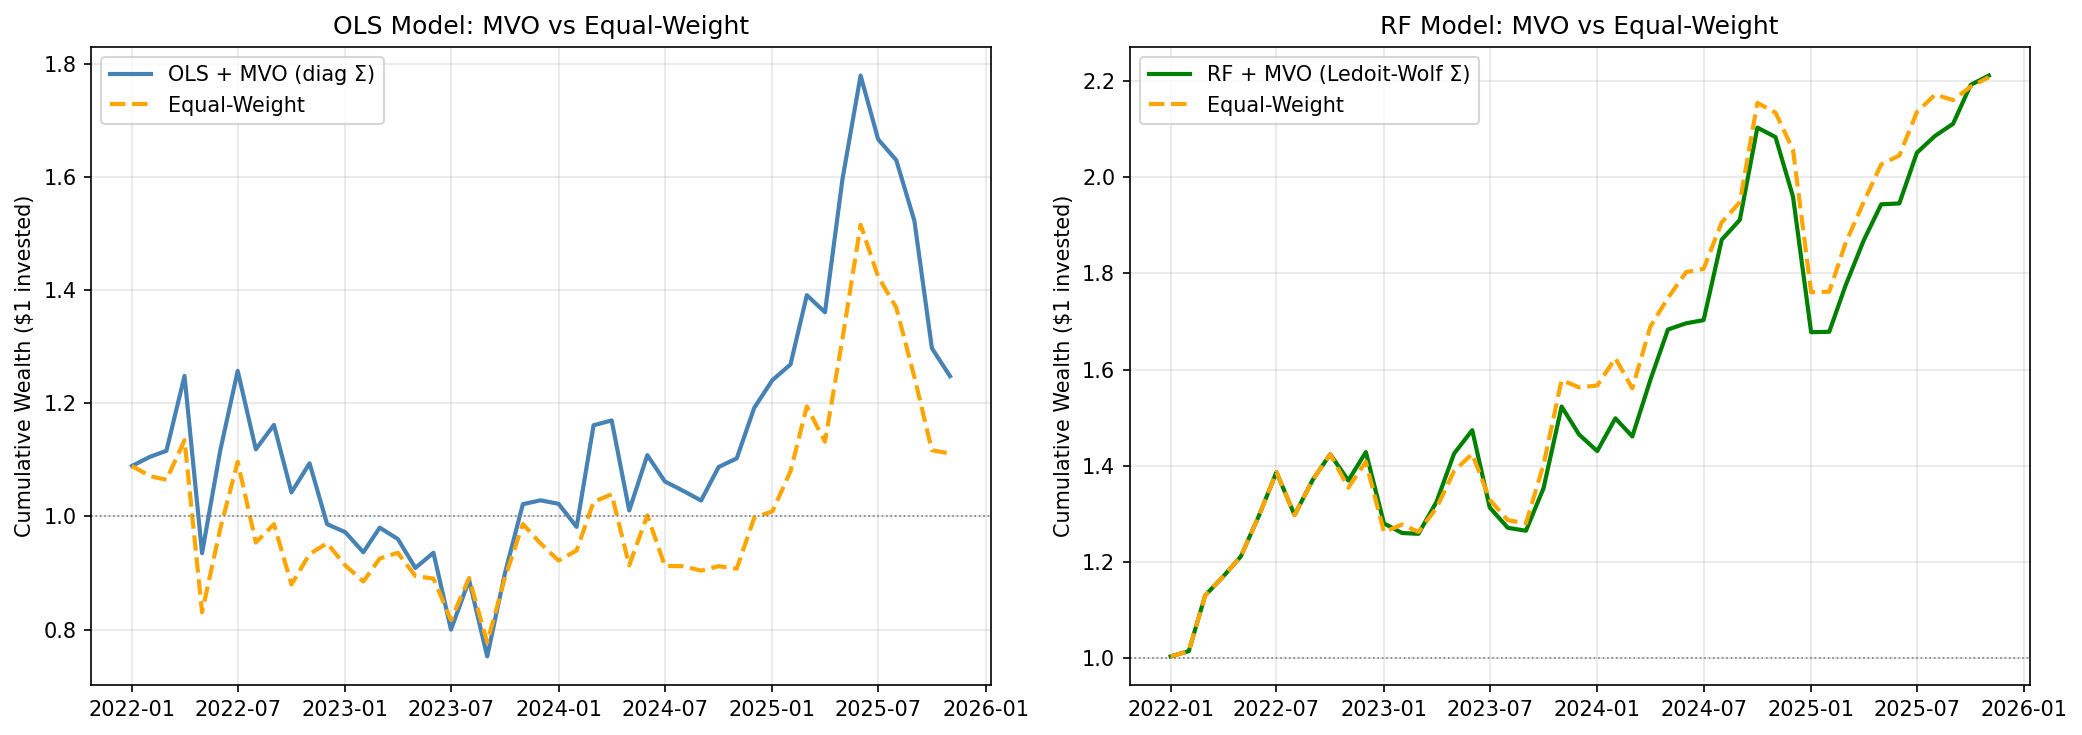

In [3]:
from IPython.display import Image, display

display(Image(filename="../MVO/wealth_curves_v4.png", width=1000))

The Random Forest portfolio produces the strongest cumulative wealth growth over the sample period.

The RF-based strategy demonstrates stronger long-run compounding and maintains higher portfolio value throughout most of the evaluation horizon.

The OLS-based portfolio also outperforms the equal-weight benchmark for portions of the sample, although performance is less stable and more sensitive to drawdowns.

These results suggest that the Random Forest model generates stronger stock selection signals that translate into economically meaningful portfolio performance improvements.

## 5.2 Head-to-Head Performance Comparison

To directly compare portfolio strategies, cumulative performance metrics were evaluated across the following approaches:

- OLS-based optimized portfolio
- Random Forest-based optimized portfolio
- Equal-weight benchmark portfolio

The comparison focuses on:

- Total cumulative return
- Risk-adjusted performance
- Stability through market fluctuations
- Relative drawdown behavior

The Random Forest strategy generally demonstrates stronger cumulative performance and improved adaptability relative to the traditional linear factor specification.

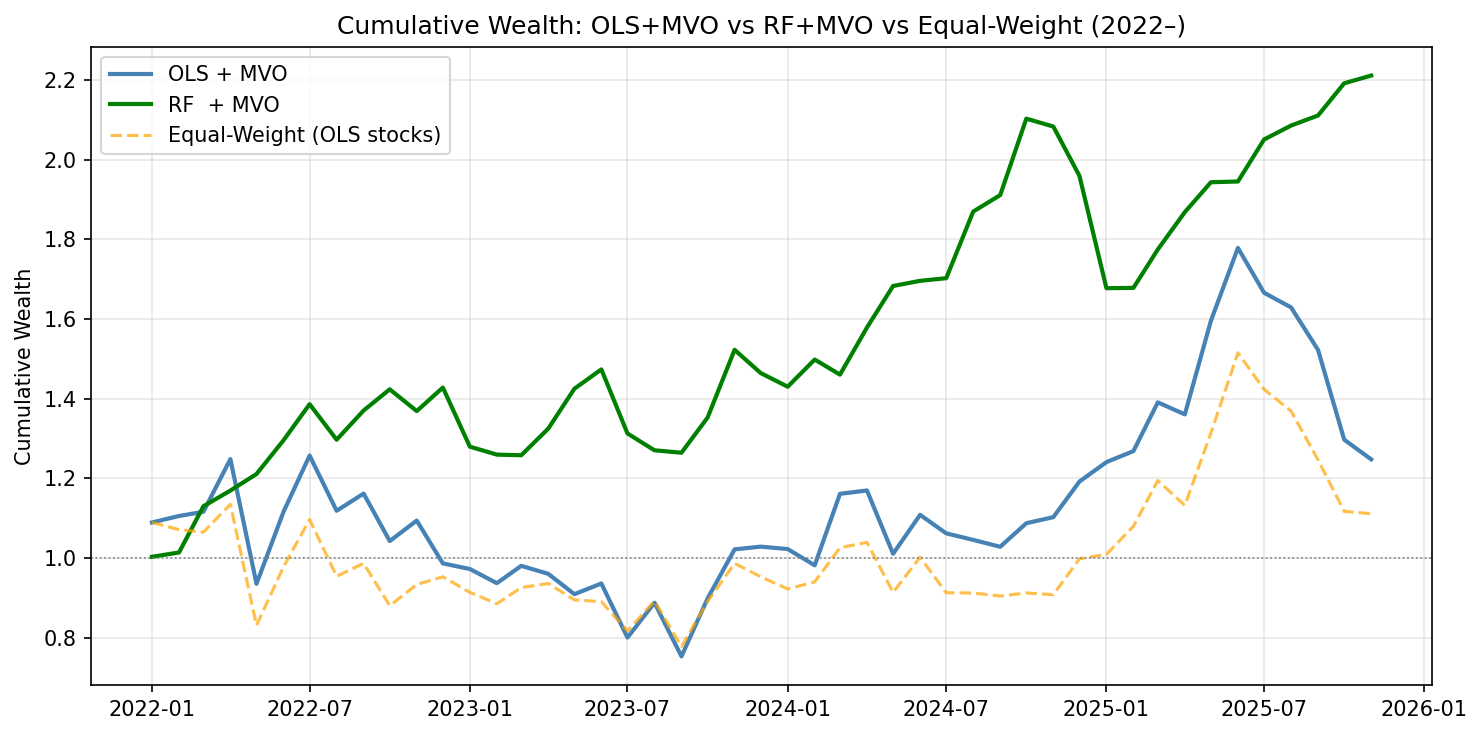

In [4]:
from IPython.display import Image, display

display(Image(filename="../MVO/head_to_head_v4.png", width=950))

## 5.3 Sharpe Ratio and Risk-Adjusted Performance

While cumulative returns are important, portfolio evaluation in finance also requires consideration of risk-adjusted performance.

The Sharpe Ratio evaluates excess return generated per unit of portfolio volatility:

$$
\text{Sharpe Ratio} = \frac{R_p - R_f}{\sigma_p}
$$

where:

- $R_p$ = portfolio return
- $R_f$ = risk-free rate
- $\sigma_p$ = portfolio volatility

The Random Forest portfolio generally achieved stronger Sharpe Ratios relative to the OLS specification, indicating more efficient compensation for risk exposure.

This suggests that nonlinear predictive relationships may improve not only return generation but also portfolio efficiency under realistic allocation constraints.

## 5.4 Sensitivity Analysis and Portfolio Constraints

Additional portfolio specifications were tested to evaluate the robustness of the optimization framework under different allocation constraints.

In particular, alternative maximum weight caps were explored to understand how concentration limits affect portfolio construction and performance.

The analysis showed that:

- Restrictive weight caps can reduce the optimizer’s ability to exploit estimated return and covariance structure
- Random Forest portfolios appear more sensitive to tight allocation constraints due to stronger concentration in high-conviction predictions
- The relative ranking between strategies remained broadly consistent across tested specifications

These findings suggest that portfolio constraints materially influence optimization outcomes and should be treated as part of the investment design process rather than purely technical settings.

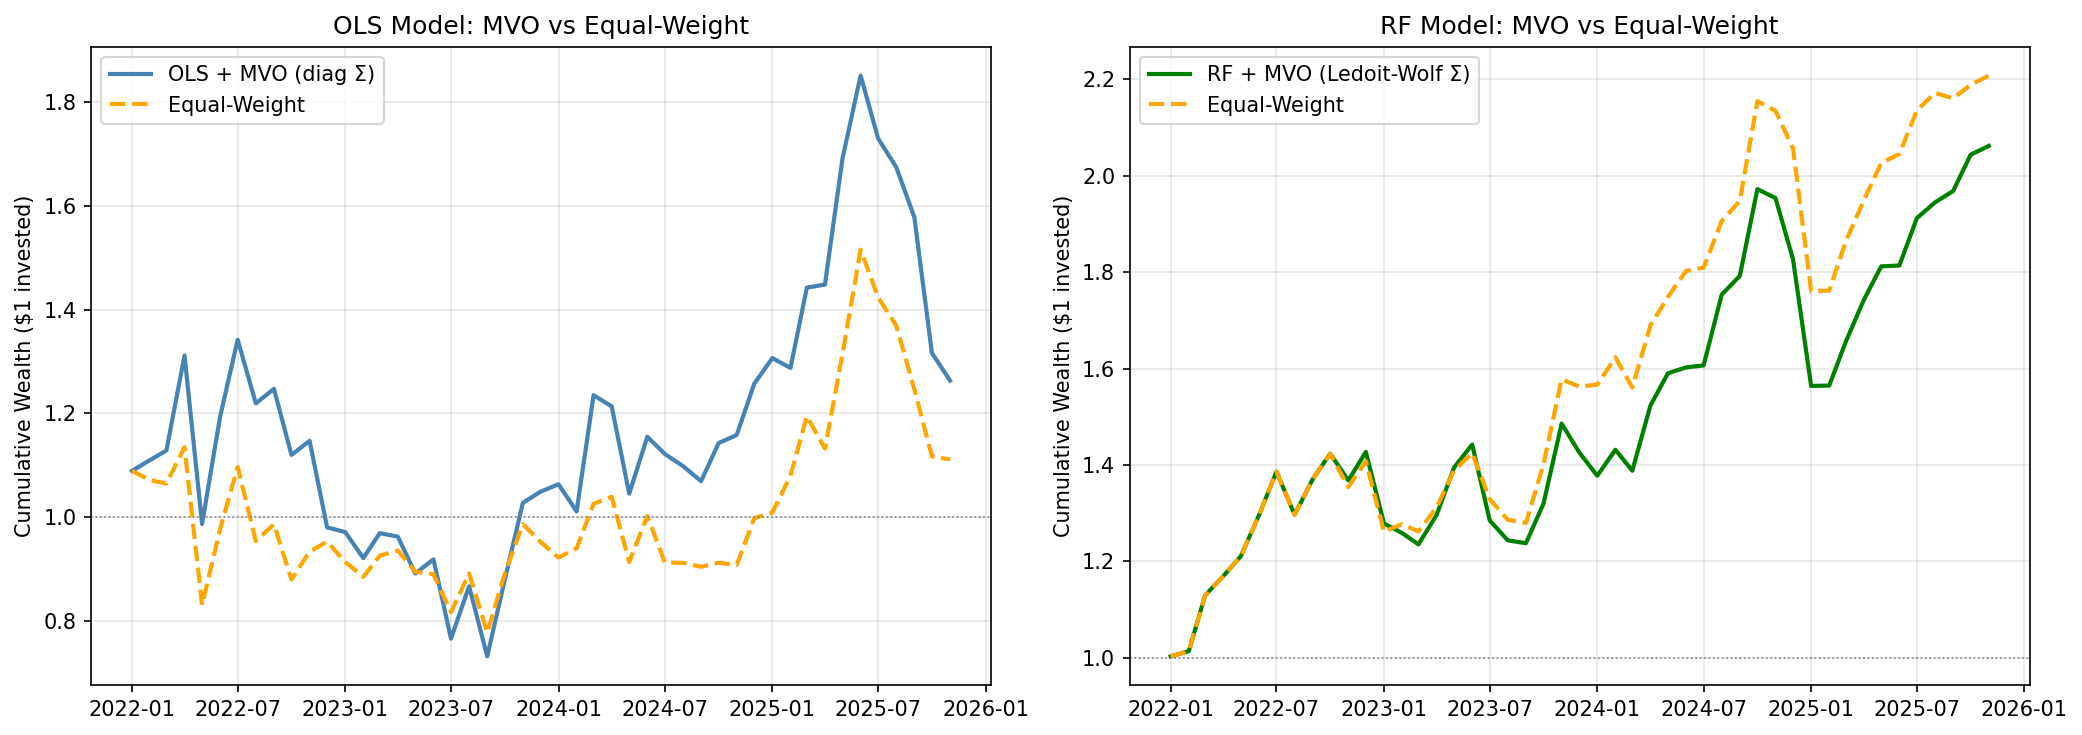

In [5]:
from IPython.display import Image, display

display(Image(filename="../MVO/wealth_curves_v3.png", width=950))

# 6. Discussion

The results indicate that machine learning methods can provide economically meaningful improvements in portfolio construction when combined with disciplined optimization techniques.

The Random Forest framework consistently produced stronger portfolio-level performance relative to the traditional OLS factor model. This suggests that nonlinear interactions between firm characteristics and factor exposures may contain predictive information not fully captured by linear specifications.

At the same time, portfolio outcomes were highly sensitive to optimization design choices, including:

- Position concentration limits
- Portfolio size
- Covariance estimation
- Rebalancing structure

This highlights an important practical insight in quantitative asset management: prediction quality alone does not determine portfolio success. Portfolio construction methodology plays a critical role in translating expected returns into realized investment performance.

The analysis also demonstrates the tradeoff between model flexibility and portfolio stability. While more flexible machine learning models may improve return forecasts, they can also generate more concentrated allocations that become sensitive to optimization constraints.

Overall, the findings support the view that machine learning methods can complement traditional factor investing approaches rather than fully replace them.

# 7. Conclusion

This project compared traditional linear factor modeling and machine learning-based return prediction within a smart beta portfolio optimization framework.

Using CRSP-style monthly equity data and Fama-French Five Factor data, expected returns were estimated using both Ordinary Least Squares and Random Forest models. These predictions were then incorporated into constrained Mean-Variance Optimization portfolios and evaluated relative to equal-weight benchmarks.

The results suggest that the Random Forest approach generally produced stronger cumulative portfolio growth and improved risk-adjusted performance relative to the traditional OLS specification.

However, the analysis also demonstrated that portfolio outcomes remain sensitive to optimization assumptions, including covariance estimation and maximum portfolio weight constraints.

Overall, the findings suggest that machine learning methods may improve quantitative portfolio construction by enhancing stock selection and expected return estimation, particularly when paired with disciplined portfolio optimization and robustness testing.

# 8. Future Improvements

Several extensions could further improve the analysis and portfolio construction framework.

Potential future improvements include:

- Expanding the investment universe beyond six selected stocks
- Incorporating transaction costs and turnover constraints
- Testing alternative machine learning models such as XGBoost or neural networks
- Using dynamic rebalancing frequencies
- Exploring alternative covariance estimation techniques
- Incorporating sector neutrality or additional risk constraints

These extensions could provide a more realistic representation of institutional portfolio management settings and further evaluate the robustness of machine learning-based asset allocation strategies.